# Molecular Dynamics in Python for NSCI0032, 24-25

This is a demonstration of a 2D Lennard Jonsium using the Velocity Verlet Integration and some integrated visualisation and postprocessing. 

It is not intended for production runs, rather it is a tool to learn molecular dynamics. 

- Authors: 
  - Tianhao Wu,  
  - Lingyun Zhao, 
  - Adham Hashibon, 
  
  (Tha Data Driven Materials Discovery Group at UCL IMD, 2024)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import ipywidgets as widgets  # not used, for future
from IPython.display import display
import nglview as nv
from io import StringIO

# Utility functions

In [5]:
# needed to convert positions to PDB for NglView (https://academic.oup.com/bioinformatics/article/34/7/1241/4721781)
def pos2pdb(positions):
    pdb_str = "MODEL\n"
    for i, pos in enumerate(positions):
        pdb_str += f"ATOM  {i+1:5d}  CA  ALA A{i+1:4d}    {pos[0]:8.3f}{pos[1]:8.3f}{0.0:8.3f}  1.00  0.00           C  \n"
    pdb_str += "ENDMDL\n"
    return pdb_str

# Set the Molecular Dynamics Parameters

In [6]:
N = 100  # Number of atoms
d = 2  # a 2D system
rho = 0.8  # The (reduced units) density (in 2D)
T0 = 0.8  # Reduced temperature (in reduced units)
Ti = T0  # Initial Temperature (in reduced units)
# the Interatomic Potential (a special case of a Materials Relation)
epsilon = 1.0
sigma = 1.0
dt = 0.0025
max_steps = 1000

# Reduced Units, in 2D and 3D 

$d=2$ for 2D and $d=3$ for 3D. 

| **Quantity**   | **Reduced Unit**                                |
|----------------|-------------------------------------------------|
| Length         | $$ r^* = \frac{r}{\sigma} $$                    |
| Energy         | $$ E^* = \frac{E}{\epsilon} $$                  |
| Time           | $$ t^* = \frac{t}{\sigma \sqrt{\frac{m}{\epsilon}}} $$ |
| Temperature    | $$ T^* = \frac{k_B T}{\epsilon} $$              |
| Density        | $$ \rho^* = \frac{N}{V \sigma^d} $$             |
| Pressure       | $$ P^* = \frac{P \sigma^d}{\epsilon} $$         |
| Force          | $$ F^* = \frac{F \sigma}{\epsilon} $$           |



# The super cell/simulation box size. 


In [7]:
# From the equation for the density. 
L = np.sqrt(N / rho)  # length of the simulation box (supercell) side.

a = L / np.sqrt(N)  # Lattice parameter 

Lx, Ly = L, L  # Simulation box size in x and y

# Create the lattice positions
positions = []
for i in range(int(np.sqrt(N))):
    for j in range(int(np.sqrt(N))):
        x = i * a
        y = j * a
        positions.append([x, y])

positions = np.array(positions)

# Generate random velocities for the particles
velocities = np.random.randn(N, d)

# Rescale velocities to match the desired initial temperature [see lecture notes]
v_s = np.sum(velocities**2, axis=1)
ke = 0.5 * np.sum(v_s)
ke_target = N * T0
scaling_factor = np.sqrt(ke_target / ke)
velocities *= scaling_factor

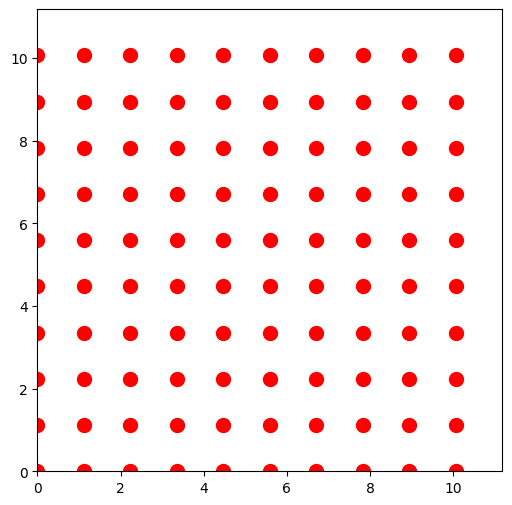

In [8]:
# Plot the initial configuration
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, L)
ax.set_ylim(0, L)
particles_plot, = ax.plot(positions[:,0], positions[:,1], 'ro', ms=10)

# Compute the Potential Energy  and the Forces 
## Reminder, the LJ potential energy and force
$V(r) = 4 \epsilon \left[ \left( \frac{\sigma}{r} \right)^{12} - \left( \frac{\sigma}{r} \right)^{6} \right]$

$F(r) = 48 \cdot \epsilon \cdot \frac{\sigma^{12}}{r^{13}} - 24 \cdot \epsilon \cdot \frac{\sigma^6}{r^7}$



In [9]:
def compute_force(positions, epsilon, sigma):   
    
    # return an array (same shape as the positions numpy array) 
    # but all elements are zero
    forces = np.zeros_like(positions) 
    
    pot_energy = 0

    for i in range(N):        
        for j in range(i + 1, N):            
            rij = positions[i] - positions[j]                        
            rij = rij - np.round(rij / L) * L  # Periodic boundary conditions
            r=np.sqrt(rij.dot(rij))
            if r<0.2: # avoid blow out due to too close, or overlaping atoms
                r=0.2    
            # force2 is the magnitude of the force!    
            force2 = 48 * epsilon * np.power(sigma, 12) / np.power(r, 13)- 24 * epsilon * np.power(sigma, 6) / np.power(r, 7)  
            force=force2*rij/r                        
            forces[i] += force            
            forces[j] -= force    
          
            # the pot energy:
            pe = 4 * epsilon * (np.power(sigma/r, 12) - np.power(sigma/r, 6))
            if pe > 1000:  # in case atoms are overlapping...
                print('posible overlap - warning', i, j, r, rij, pe)
            pot_energy = pot_energy + pe

    return forces, pot_energy

# The kinetic energy and Temperature

In [17]:
def compute_kinetic_energy(velocities):
    kinetic_energy = 0.5 * np.sum(velocities**2)
    temperature = kinetic_energy / N  # Equipartition Theorem in 2D!
    return kinetic_energy, temperature

# Update positions and velocities using Verlet integration

In [18]:
def update_positions(positions, velocities, forces, epsilon, sigma, dt):

    # First update positions based on current velocities and forces (Verlet step 1) or the  **first half-step of the Velocity Verlet method**
    positions += velocities * dt + 0.5 * forces * dt ** 2
    
    positions %= L  #  periodic boundary conditions
    
    # Calculate new forces after updating positions
    new_forces, pot_energy = compute_force(positions, epsilon, sigma)
    
    # Update velocities (Verlet step 2 or second half step)
    velocities += 0.5 * (forces + new_forces) * dt

    return positions, velocities, new_forces, pot_energy

In [19]:
# Initialize forces
forces, pot_energy = compute_force(positions, epsilon, sigma)

# Initialize an array to store positions for all steps
all_positions = np.zeros((max_steps, N, 2))

In [20]:
stats=[] # stores the thermodynamical statistical variables

with open("simulation_results.dat", "w") as f:
    f.write('#Step   Etot   PotE Ktot  T\n')
    
    for step in range(max_steps):
        positions, velocities, forces, pot_energy = update_positions(positions, velocities, forces, epsilon, sigma, dt)
        kinetic_energy, temperature = compute_kinetic_energy(velocities)
        tot_energy = pot_energy + kinetic_energy
        
        all_positions[step] = positions
                
        f.write(f"{step} {tot_energy/N:.6f} {pot_energy/N:.6f}  {kinetic_energy/N:.6f} {temperature:.2f}\n")
        stats.append([step, tot_energy/N, pot_energy/N, kinetic_energy/N, temperature])
        
stats = np.array(stats)


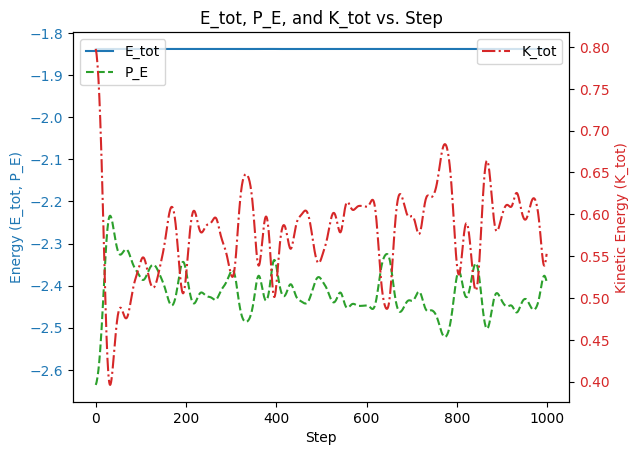

In [21]:
step = stats[:, 0]  
E_tot = stats[:, 1]  
P_E = stats[:, 2]  
K_tot = stats[:, 3]  
T     = stats[:,4]

fig, ax1 = plt.subplots()

ax1.set_xlabel('Step')
ax1.set_ylabel('Energy (E_tot, P_E)', color='tab:blue')
ax1.plot(step, E_tot, label='E_tot', color='tab:blue', linestyle='-')
ax1.plot(step, P_E, label='P_E', color='tab:green', linestyle='--')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')

# Create a second y-axis (y2) sharing the same x-axis
ax2 = ax1.twinx()
ax2.set_ylabel('Kinetic Energy (K_tot)', color='tab:red')
ax2.plot(step, K_tot, label='K_tot', color='tab:red', linestyle='-.')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.legend(loc='upper right')

# Add a title and display the plot
plt.title('E_tot, P_E, and K_tot vs. Step')
plt.show()

# Some fancy visualisation

In [23]:
pdb_data = pos2pdb(positions)
pdb_file = StringIO(pdb_data)

In [24]:
view = nv.show_file(pdb_file, ext='pdb')
#view.add_ball_and_stick()  # Add ball-and-stick representation for visualization
view.clear_representations()
view.add_spacefill(radiusType='vdw', radius=.1)
view.add_spacefill(radiusScale=.1) # Space-filling representation

In [25]:
view

NGLWidget()

# Animation 
This is a simple one, but you can if you like modify it to use nglview...

Once run, look for the file `vis.gif`

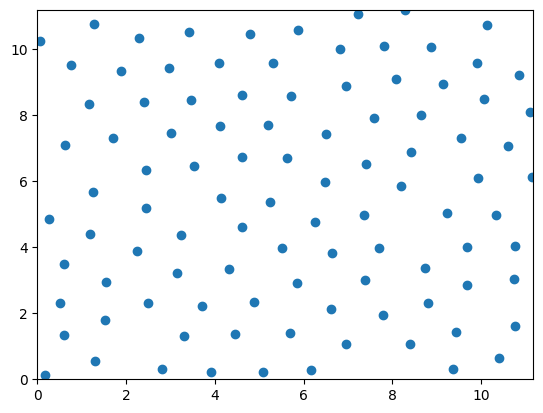

In [29]:
fig, ax = plt.subplots()
scat = ax.scatter([], [])

ax.set_xlim(0, L)
ax.set_ylim(0, L)

def update(frame):
    scat.set_offsets(all_positions[frame]) 
    return scat,

ani = animation.FuncAnimation(fig=fig, func=update, frames=max_steps, interval=100, blit=True)

ani.save(filename="vis.gif", writer="pillow")